## Import Library

In [23]:
# Import library untuk manipulasi data dan machine learning
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Import library untuk visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Import library untuk model regresi dan evaluasi
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Membaca Dataset

In [10]:
# Ganti 'sample_meetup.csv' jika nama file Anda berbeda
df = pd.read_csv('/content/sample_meetup.csv', sep=';')

print("Dataset awal berhasil dimuat.")
print("Dimensi data (baris, kolom):", df.shape)
df.info()

Dataset awal berhasil dimuat.
Dimensi data (baris, kolom): (220, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   date             220 non-null    object 
 1   state            220 non-null    object 
 2   category         220 non-null    object 
 3   time             220 non-null    object 
 4   groupname        184 non-null    object 
 5   name             184 non-null    object 
 6   attendees_count  184 non-null    float64
 7   Unnamed: 7       0 non-null      float64
dtypes: float64(2), object(6)
memory usage: 13.9+ KB


## Data Cleaning

In [11]:
print("Memulai proses data cleaning...")

# Menghapus kolom 'Unnamed: 7' jika ada
if 'Unnamed: 7' in df.columns:
    df = df.drop(columns=['Unnamed: 7'])

# Menghapus data duplikat
initial_rows = len(df)
df.drop_duplicates(inplace=True)
print(f"Menghapus {initial_rows - len(df)} baris duplikat.")

# Mengisi nilai kosong (missing values)
df['attendees_count'] = df['attendees_count'].fillna(df['attendees_count'].median())
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].fillna(df[col].mode()[0])
print("Nilai kosong telah diisi.")

print("\nData cleaning selesai. Dimensi data sekarang:", df.shape)

Memulai proses data cleaning...
Menghapus 21 baris duplikat.
Nilai kosong telah diisi.

Data cleaning selesai. Dimensi data sekarang: (199, 7)


Proses pembersihan data dilakukan di sini:
 1.  Kolom 'Unnamed: 7' yang tidak relevan dihapus.
 2.  Baris data yang duplikat dibuang.
 3.  Nilai yang hilang (missing values) diisi menggunakan median untuk kolom numerik dan modus untuk kolom kategorikal.

## Menangani Outlier

In [12]:
print("Menangani outlier pada 'attendees_count'...")

# Menghitung batas atas dan bawah menggunakan metode IQR
Q1 = df['attendees_count'].quantile(0.25)
Q3 = df['attendees_count'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Mengganti nilai outlier dengan nilai batas (capping)
df['attendees_count'] = df['attendees_count'].clip(lower=lower_bound, upper=upper_bound)

print("Outlier selesai ditangani.")
df['attendees_count'].describe()

Menangani outlier pada 'attendees_count'...
Outlier selesai ditangani.


,attendees_count
count,199.000000
mean,16.969849
std,15.435974
min,1.000000
25%,6.000000
50%,10.000000
75%,23.000000
max,48.500000


Outlier pada kolom target `attendees_count` ditangani menggunakan metode IQR (Interquartile Range). Nilai yang berada di luar batas atas dan bawah akan diganti dengan nilai batas tersebut (capping) untuk mengurangi dampaknya pada model.

## Encoding Kolom Kategorikal

In [13]:
print("Mengubah kolom kategorikal (teks) menjadi angka...")

label_encoder = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = label_encoder.fit_transform(df[col])

print("Encoding selesai.")
df.head()

Mengubah kolom kategorikal (teks) menjadi angka...
Encoding selesai.


,date,state,category,time,groupname,name,attendees_count
0,0,0,0,24,97,157,6.0
1,0,0,0,40,131,83,48.5
2,0,0,0,42,38,177,10.0
3,0,0,0,43,35,37,4.0
4,0,0,0,43,35,38,3.0


Model machine learning memerlukan input berupa angka. Oleh karena itu, semua kolom yang berisi teks (kategorikal) diubah menjadi format numerik menggunakan `LabelEncoder`.

## Memisahkan Fitur (X) dan Target (y)

In [14]:
# X berisi semua kolom KECUALI 'attendees_count'
X = df.drop(columns=['attendees_count'])

# y hanya berisi kolom 'attendees_count'
y = df['attendees_count']

print("Fitur (X) dan Target (y) telah dipisahkan.")
print("Dimensi X:", X.shape)
print("Dimensi y:", y.shape)

Fitur (X) dan Target (y) telah dipisahkan.
Dimensi X: (199, 6)
Dimensi y: (199,)


`X`: Fitur atau variabel independen yang akan digunakan untuk membuat prediksi.
`y`: Target atau variabel dependen yang ingin diprediksi (`attendees_count`).

## Scaling Data

In [15]:
# Scaling fitur (X)
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X)

# Scaling target (y)
scaler_y = StandardScaler()
# y.values.reshape(-1, 1) diperlukan karena scaler mengharapkan input 2D
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1))

print("Scaling data selesai.")

Scaling data selesai.


Fitur (X) dan target (y) diskalakan menggunakan `StandardScaler`. Ini penting untuk menyamakan rentang nilai antar kolom, sehingga performa model regresi menjadi lebih baik dan stabil.

## Membagi Data Training dan Testing

In [16]:
# Membagi data dengan perbandingan 80% training dan 20% testing
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)

print("Data berhasil dibagi menjadi set training dan testing.")
print("Ukuran X_train:", X_train.shape)
print("Ukuran X_test:", X_test.shape)

Data berhasil dibagi menjadi set training dan testing.
Ukuran X_train: (159, 6)
Ukuran X_test: (40, 6)


 Data yang sudah bersih dan diskalakan dibagi menjadi dua set:
**Training Set (80%):** Digunakan untuk melatih model.
 **Testing Set (20%):** Digunakan untuk menguji performa model pada data yang belum pernah dilihat sebelumnya.

## Implementasi Metode Supervised Learning

In [17]:
#-----------------------------------------------------------
# Implementasi Metode Supervised Learning (Linear Regression)
#-----------------------------------------------------------
print("--- Memulai Training Model Linear Regression ---")

# Inisialisasi model Linear Regression
lr_model = LinearRegression()

# Melatih model dengan data training
# Kita menggunakan data yang sudah di-scaling
lr_model.fit(X_train, y_train)

print("Training model Linear Regression selesai.")

--- Memulai Training Model Linear Regression ---
Training model Linear Regression selesai.


Model `LinearRegression` diinisialisasi dan dilatih menggunakan data training yang sudah dipersiapkan (`X_train` dan `y_train`).

## Evaluasi Hasil Prediksi (Linear Regression)

In [18]:
#-----------------------------------------------------------
# A2. Evaluasi Hasil Prediksi (Linear Regression)
#-----------------------------------------------------------
print("--- Mengevaluasi Model Linear Regression pada Data Test ---")

# Melakukan prediksi pada data test
predictions_scaled_lr = lr_model.predict(X_test)

# Mengembalikan prediksi dan y_test ke skala aslinya
predictions_lr = scaler_y.inverse_transform(predictions_scaled_lr)
y_test_original = scaler_y.inverse_transform(y_test)

# Menghitung metrik evaluasi
mae_lr = mean_absolute_error(y_test_original, predictions_lr)
mse_lr = mean_squared_error(y_test_original, predictions_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test_original, predictions_lr)

print(f"\n--- Hasil Evaluasi Linear Regression ---")
print(f"Mean Absolute Error (MAE): {mae_lr:.2f}")
print(f"Mean Squared Error (MSE): {mse_lr:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_lr:.2f}")
print(f"R2-Score: {r2_lr:.2f}")

--- Mengevaluasi Model Linear Regression pada Data Test ---

--- Hasil Evaluasi Linear Regression ---
Mean Absolute Error (MAE): 12.38
Mean Squared Error (MSE): 239.10
Root Mean Squared Error (RMSE): 15.46
R2-Score: 0.02


Performa model dievaluasi pada data test. Hasil prediksi diubah kembali ke skala aslinya untuk dihitung metrik evaluasi: MAE, MSE, RMSE, dan R2-Score.

* **MAE & RMSE (12.38 & 15.46):** Rata-rata, prediksi model ini meleset sekitar 12-15 peserta dari jumlah sebenarnya.
* **R2-Score (0.02):** Nilai yang sangat rendah ini menunjukkan model **sangat lemah**. Model ini hampir tidak memiliki kemampuan untuk menjelaskan variasi data jumlah peserta.

## Plot Hasil Prediksi (Linear Regression)

--- Membuat Plot Hasil Prediksi vs Nilai Asli ---


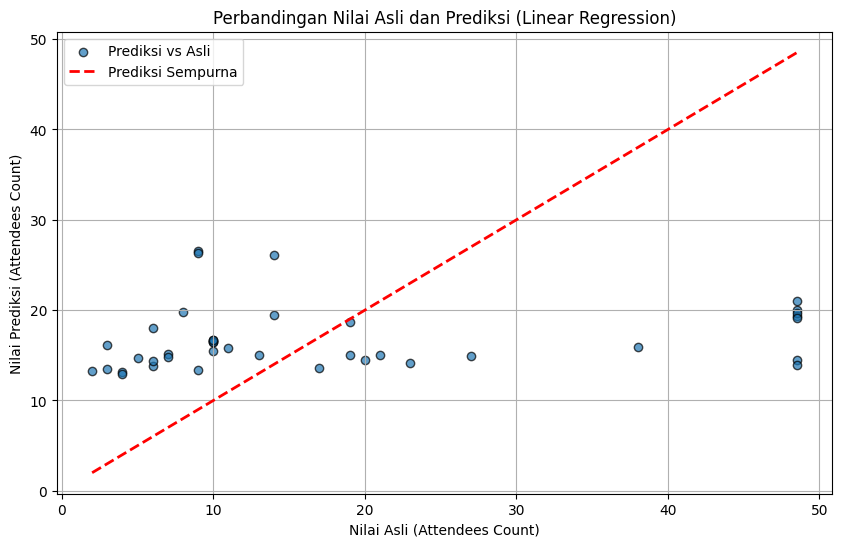

In [24]:
#----------------------------------------
# Plot Hasil Prediksi (Linear Regression)
#----------------------------------------
print("--- Membuat Plot Hasil Prediksi vs Nilai Asli ---")

plt.figure(figsize=(10, 6))
# Membuat scatter plot: sumbu x adalah nilai asli, sumbu y adalah prediksi
plt.scatter(y_test_original, predictions_lr, alpha=0.7, edgecolors='k', label='Prediksi vs Asli')

# Menambahkan garis diagonal y=x sebagai referensi prediksi sempurna
plt.plot([y_test_original.min(), y_test_original.max()], [y_test_original.min(), y_test_original.max()], 'r--', lw=2, label='Prediksi Sempurna')

plt.title('Perbandingan Nilai Asli dan Prediksi (Linear Regression)')
plt.xlabel('Nilai Asli (Attendees Count)')
plt.ylabel('Nilai Prediksi (Attendees Count)')
plt.legend()
plt.grid(True)
plt.show()

Visualisasi perbandingan antara nilai asli (`y_test_original`) dengan nilai yang diprediksi oleh model (`predictions_lr`). Garis putus-putus merah menunjukkan prediksi yang sempurna. Semakin dekat titik-titik biru ke garis merah, semakin baik performa model.

## Implementasi Metode: SVR

In [20]:
#------------------------------------------------
#  Implementasi Support Vector Regressor (SVR)
#------------------------------------------------
print("\n--- Memulai Training Model SVR (Point Plus) ---")

# Inisialisasi model SVR
svr_model = SVR(kernel='rbf') # Kita gunakan kernel RBF yang umum

# Melatih model SVR
# SVR memerlukan input y dalam bentuk 1D, jadi kita gunakan .ravel()
svr_model.fit(X_train, y_train.ravel())

print("Training model SVR selesai.")


--- Memulai Training Model SVR (Point Plus) ---
Training model SVR selesai.


model `Support Vector Regressor (SVR)` dengan kernel `rbf` diinisialisasi dan dilatih menggunakan data training yang sama.

Evaluasi Hasil Prediksi (SVR)

In [21]:
#-----------------------------
# Evaluasi Hasil Prediksi SVR
#-----------------------------
print("--- Mengevaluasi Model SVR pada Data Test ---")

# Melakukan prediksi
predictions_scaled_svr = svr_model.predict(X_test)

# Mengembalikan prediksi ke skala asli
# Hasil predict() SVR adalah 1D, jadi tidak perlu reshape
predictions_svr = scaler_y.inverse_transform(predictions_scaled_svr.reshape(-1, 1))

# Menghitung metrik evaluasi
mae_svr = mean_absolute_error(y_test_original, predictions_svr)
mse_svr = mean_squared_error(y_test_original, predictions_svr)
rmse_svr = np.sqrt(mse_svr)
r2_svr = r2_score(y_test_original, predictions_svr)

print(f"\n--- Hasil Evaluasi SVR ---")
print(f"Mean Absolute Error (MAE): {mae_svr:.2f}")
print(f"Mean Squared Error (MSE): {mse_svr:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_svr:.2f}")
print(f"R2-Score: {r2_svr:.2f}")

--- Mengevaluasi Model SVR pada Data Test ---

--- Hasil Evaluasi SVR ---
Mean Absolute Error (MAE): 11.88
Mean Squared Error (MSE): 307.38
Root Mean Squared Error (RMSE): 17.53
R2-Score: -0.25


Performa model SVR dievaluasi dengan metrik yang sama seperti sebelumnya untuk membandingkan hasilnya dengan Linear Regression.

* **MAE & RMSE (11.88 & 17.53):** Rata-rata kesalahan prediksi model SVR adalah sekitar 12-17 peserta.
* **R2-Score (-0.25):** Nilai R2 yang **negatif** menandakan bahwa performa model ini **sangat buruk**, bahkan lebih buruk daripada sekadar menebak nilai rata-rata. Model ini tidak cocok untuk data ini.

## Plot Hasil Prediksi (SVR)

--- Membuat Plot Hasil Prediksi vs Nilai Asli (SVR) ---


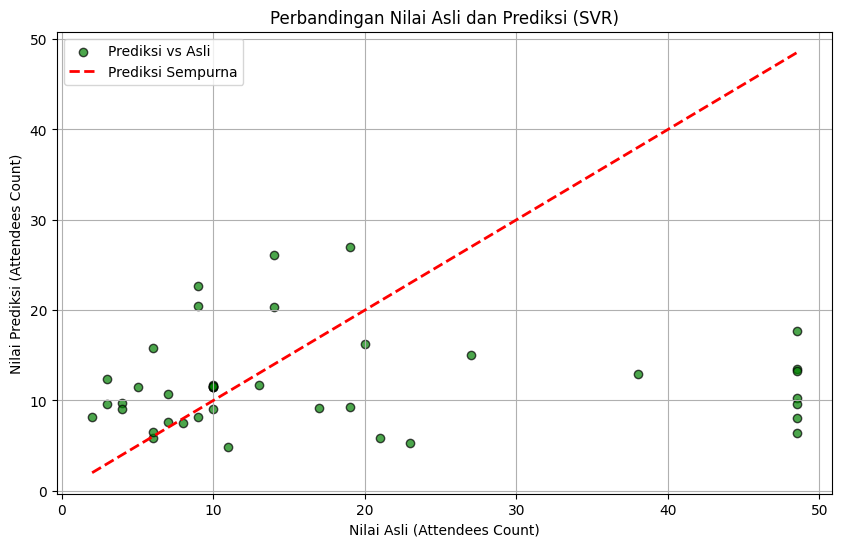

In [22]:
#----------------------------
#  Plot Hasil Prediksi SVR
#----------------------------
print("--- Membuat Plot Hasil Prediksi vs Nilai Asli (SVR) ---")

plt.figure(figsize=(10, 6))
plt.scatter(y_test_original, predictions_svr, alpha=0.7, edgecolors='k', color='green', label='Prediksi vs Asli')
plt.plot([y_test_original.min(), y_test_original.max()], [y_test_original.min(), y_test_original.max()], 'r--', lw=2, label='Prediksi Sempurna')

plt.title('Perbandingan Nilai Asli dan Prediksi (SVR)')
plt.xlabel('Nilai Asli (Attendees Count)')
plt.ylabel('Nilai Prediksi (Attendees Count)')
plt.legend()
plt.grid(True)
plt.show()

 Visualisasi perbandingan untuk model SVR. Terlihat dari plot bahwa sebaran titik-titik hijau (prediksi) sangat jauh dari garis prediksi sempurna, yang mengonfirmasi hasil R2-Score yang negatif.